# team4d - predicting future estuary water health based on climate data

This template should get the whole thing going

Please rewrite this eventually

## NOTE

The original 15min resolution was scanned, already, for nutrient data that wasn't recorded precisely at 0, 4, 8, 12, 16, or 20 o'clock, and 'as of' forwarded up to a week... so any that was recorded at, say, 9:15am, will still be around for the 8pm and 8am next day water quality measures that we'd choose to keep.  Pre-cleaned during collation.  But that's the only cleaning or imputation done so far.


## 1) dependencies

In [1]:
# basic tools for paths and tables
# presently running on python 3.13.* in a venv
from pathlib import Path

import numpy as np                  # for arrays and math
import pandas as pd                 # for dataframes and csv I/O
import matplotlib.pyplot as plt     # basic visualizations
import seaborn as sns               # for quick readable charts

# keep charts easy to read
sns.set_theme( style = 'whitegrid' )


## 2) load file

look in ../Data/Team4D for a combined csv first


In [2]:
# path is relative to /Code where this notebook lives
resolution = 1 # hours per time step in the data
data_dir = Path( f'../data/{resolution}hr' )
file_name = f't4d.baseline.{resolution}hr.csv'
data_path = data_dir / file_name

# if this folder is missing, stop early with a clear message
if not data_dir.exists( ):
    raise FileNotFoundError( f'missing folder: {data_dir.resolve()}' )

# read the combined working file
data = pd.read_csv( data_path )


/var/folders/fr/4m_77r353cs6l44l0mrx2cr00000gn/T/ipykernel_7627/341055212.py:12: DtypeWarning: Columns (0: meta_replicate, 1: meta_f_record, 2: n_po4f_flag, 3: n_nh4f_flag, 4: n_no2f_flag, 5: n_no3f_flag, 6: n_no23f_flag, 7: n_chla_flag, 8: meta_frequency_min, 9: m_nerrs_rh_pct, 10: m_nerrs_bp_hpa, 11: m_nerrs_wspd_m_s, 12: m_nerrs_max_wspd_m_s, 13: m_nerrs_max_wspd_time_hhmm, 14: m_nerrs_wdir_deg, 15: m_nerrs_wdir_sd_deg, 16: m_nerrs_par_umol_m2_s, 17: m_nerrs_precip_mm, 18: m_nerrs_solar_rad_w_m2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv( data_path )


## 3) quick stats and structure

first look at shape columns and missing values


In [3]:
# row and column count
print( 'shape:', data.shape )

# keep the first numeric summary focused on measured values, not QA flag codes
summary_num_cols = [ col for col in data.select_dtypes( include = [ np.number ] ).columns if not col.endswith( '_flag' ) ]

data[ summary_num_cols ].describe( ).round( 3 ).T


shape: (25277923, 72)


,count,mean,std,min,25%,50%,75%,max
meta_historical,25277923.0,0.868,0.339,0.000,1.000,1.000,1.000,1.000
meta_provisional_plus,25277923.0,0.943,0.232,0.000,1.000,1.000,1.000,1.000
meta_collection_method,16932.0,1.867,0.340,1.000,2.000,2.000,2.000,2.000
n_po4f_mg_l,4389967.0,0.036,0.202,0.000,0.007,0.019,0.041,21.961
n_nh4f_mg_l,4356202.0,0.097,4.461,-0.061,0.013,0.032,0.068,506.337
n_no2f_mg_l,3024927.0,0.009,0.097,-0.012,0.002,0.004,0.008,4.000
n_no3f_mg_l,2255419.0,0.263,0.443,-0.264,0.014,0.099,0.335,8.886
n_no23f_mg_l,4378310.0,0.166,0.361,0.000,0.007,0.033,0.166,8.938
n_chla_ug_l,4336323.0,9.469,19.274,-11.500,2.070,4.500,9.800,1074.680
w_temp_c,19931828.0,18.409,9.006,-996.300,12.000,18.600,25.700,615.800


## 4) cleaning and repair

simple cleanup before analysis


In [4]:
# make column names easier to work with
data.columns = ( 
    data.columns
    .str.strip( )
    .str.lower( )
    .str.replace( ' ', '_', regex = False )
    .str.replace( '-', '_', regex = False )
)

# make sure time is a real datetime before we sort or shift later
if 'meta_datetime_stamp' in data.columns:
    data[ 'meta_datetime_stamp' ] = pd.to_datetime( data[ 'meta_datetime_stamp' ], errors = 'coerce' )

# remove duplicate rows
before = len( data )
data = data.drop_duplicates( ).copy( )
after = len( data )
print( 'duplicates removed:', before - after )

duplicates removed: 0


## re: nutrients

| Parameter             | Low        | Moderate | Eutrophic |
| --------------------- | ---------- | -------- | --------- |
| NO₃⁻+NO₂⁻ (mg/L as N) | <0.05      | 0.05–0.5 | 0.5–2+    |
| NH₄⁺ (mg/L as N)      | <0.02      | 0.02–0.2 | 0.2–1+    |
| TN (mg/L)             | 0.2–0.5    | 0.5–1.5  | 1.5–5     |
| PO₄³⁻ (mg/L as P)     | 0.005–0.02 | 0.02–0.1 | 0.1–0.5   |
| TP (mg/L)             | 0.02–0.05  | 0.05–0.2 | 0.2–1     |
| Chlorophyll-a (µg/L)  | <5         | 5–20     | 20–60+    |

circa [www.epa.gov (pdf)](https://www.epa.gov/sites/default/files/2018-10/documents/nutrient-criteria-manual-estuarine-coastal.pdf)

In [5]:
# trim spaces in text columns
text_cols = data.select_dtypes( include = 'object' ).columns
for col in text_cols:
    data[ col ] = data[ col ].astype( str ).str.strip( )

# convert ERA5 air temperature from Kelvin to Celsius
if 'm_era5_air_temp_k' in data.columns:
    data[ 'm_era5_air_temp_k' ] = pd.to_numeric( data[ 'm_era5_air_temp_k' ], errors = 'coerce' )
    data[ 'm_era5_air_temp_c' ] = data[ 'm_era5_air_temp_k' ] - 273.15

# convert hourly ERA5 solar energy to a smaller unit that is easier to read in tables and charts
# this stays as energy per square meter over the hour, just expressed in kWh instead of joules
if 'm_era5_ssrd_j_m2' in data.columns:
    data[ 'm_era5_ssrd_j_m2' ] = pd.to_numeric( data[ 'm_era5_ssrd_j_m2' ], errors = 'coerce' )
    data[ 'm_era5_ssrd_kwh_m2' ] = data[ 'm_era5_ssrd_j_m2' ] / 3600000

# set generous physical limits so obviously impossible values become missing
# these are not meant to remove every outlier, only impossible records
clean_limits = { 
    'n_nh4f_mg_l': ( 0, 1000 ),
    'n_no2f_mg_l': ( 0, 1000 ),
    'n_no3f_mg_l': ( 0, 1000 ),
    'n_po4f_mg_l': ( 0, 1000 ),
    'n_no23f_mg_l': ( 0, 1000 ),
    'n_chla_ug_l': ( 0, 1000 ),
    'w_temp_c': ( -5, 45 ),
    'm_nerrs_air_temp_c': ( -40, 60 ),
    'm_era5_air_temp_c': ( -40, 60 ),
    'w_ph': ( 0, 14 ),
    'w_sal_psu': ( 0, 60 ),
    'w_do_pct': ( 0, 300 ),
    'w_do_mg_l': ( 0, 30 ),
    'w_depth_m': ( 0, 100 ),
    'w_cdepth_m': ( 0, 100 ),
    'w_level_m': ( -10, 10 ),
    'w_clevel_m': ( -10, 10 ),
    'w_turb_ntu': ( 0, 5000 ),
    'w_chlfluor_au': ( 0, 1000 ),
    'm_nerrs_solar_rad_w_m2': ( 0, 1500 ),
    'm_nerrs_par_umol_m2_s': ( 0, 3000 ),
    'm_nerrs_precip_mm': ( 0, 500 ),
}

# keep a log of how many values were turned into missing values
clean_log_rows = [ ]

for col, ( low_ok, high_ok ) in clean_limits.items( ):
    if col in data.columns:
        data[ col ] = pd.to_numeric( data[ col ], errors = 'coerce' )
        bad_mask = data[ col ].notna( ) & ( ( data[ col ] < low_ok ) | ( data[ col ] > high_ok ) )
        clean_log_rows.append( { 
            'column': col,
            'low_ok': low_ok,
            'high_ok': high_ok,
            'n_set_to_missing': int( bad_mask.sum( ) ),
        } )
        data.loc[ bad_mask, col ] = np.nan

clean_log = pd.DataFrame( clean_log_rows ).sort_values( 'n_set_to_missing', ascending = False )
print( 'cleaning summary:' )
print( clean_log )

# drop the raw Kelvin field now that the Celsius version exists
drop_now_cols = [ ]

if 'm_era5_air_temp_k' in data.columns and 'm_era5_air_temp_c' in data.columns:
    drop_now_cols.append( 'm_era5_air_temp_k' )

if 'm_era5_ssrd_j_m2' in data.columns and 'm_era5_ssrd_kwh_m2' in data.columns:
    drop_now_cols.append( 'm_era5_ssrd_j_m2' )

if drop_now_cols:
    print( )
    print( 'dropping duplicate-unit columns now:' )
    print( drop_now_cols )
    data = data.drop( columns = drop_now_cols )

else:
    print( )
    print( 'no duplicate-unit columns were dropped' )

# fully empty columns are worth reviewing, but do not auto-drop them here
all_missing_cols = [ col for col in data.columns if data[ col ].isna( ).all( ) ]
print( )
print( 'fully empty columns to review later:' )
print( all_missing_cols )


/var/folders/fr/4m_77r353cs6l44l0mrx2cr00000gn/T/ipykernel_7627/1326849267.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes( include = 'object' ).columns


cleaning summary:
                    column  low_ok  high_ok  n_set_to_missing
17              w_turb_ntu       0     5000            412235
11                w_do_pct       0      300             63931
13               w_depth_m       0      100             62816
18           w_chlfluor_au       0     1000             54311
12               w_do_mg_l       0       30             54108
6                 w_temp_c      -5       45             40723
9                     w_ph       0       14             31328
10               w_sal_psu       0       60             24691
2              n_no3f_mg_l       0     1000             16016
14              w_cdepth_m       0      100              7268
15               w_level_m     -10       10              6225
1              n_no2f_mg_l       0     1000               519
5              n_chla_ug_l       0     1000               506
0              n_nh4f_mg_l       0     1000                 2
7       m_nerrs_air_temp_c     -40       60         

In [6]:
# build one combined air-temperature field for later comparisons
# prefer NERRS air temp, then fall back to ERA5 air temp if needed
data[ 'air_temp_c' ] = np.nan

if 'm_era5_air_temp_c' in data.columns:
    data[ 'air_temp_c' ] = data[ 'm_era5_air_temp_c' ]

if 'm_nerrs_air_temp_c' in data.columns:
    data[ 'air_temp_c' ] = data[ 'm_nerrs_air_temp_c' ].fillna( data[ 'air_temp_c' ] )

data[ 'air_temp_source' ] = pd.NA

if 'm_era5_air_temp_c' in data.columns:
    data.loc[ data[ 'm_era5_air_temp_c' ].notna( ), 'air_temp_source' ] = 'era5'

if 'm_nerrs_air_temp_c' in data.columns:
    data.loc[ data[ 'm_nerrs_air_temp_c' ].notna( ), 'air_temp_source' ] = 'nerrs'

print( )
print( 'air temperature source counts:' )
print( data[ 'air_temp_source' ].value_counts( dropna = False ) )

# build one canonical depth field
# prefer corrected depth, but fall back to raw depth so we keep usable rows
data[ 'depth_m' ] = np.nan

if 'w_depth_m' in data.columns:
    data[ 'depth_m' ] = data[ 'w_depth_m' ]

if 'w_cdepth_m' in data.columns:
    data[ 'depth_m' ] = data[ 'w_cdepth_m' ].fillna( data[ 'depth_m' ] )

data[ 'depth_source' ] = pd.NA

if 'w_depth_m' in data.columns:
    data.loc[ data[ 'w_depth_m' ].notna( ), 'depth_source' ] = 'raw_depth'

if 'w_cdepth_m' in data.columns:
    data.loc[ data[ 'w_cdepth_m' ].notna( ), 'depth_source' ] = 'corrected_depth'

data[ 'depth_flag' ] = np.nan

if 'w_depth_flag' in data.columns:
    data[ 'depth_flag' ] = pd.to_numeric( data[ 'w_depth_flag' ], errors = 'coerce' )

if 'w_cdepth_flag' in data.columns:
    data[ 'depth_flag' ] = pd.to_numeric( data[ 'w_cdepth_flag' ], errors = 'coerce' ).fillna( data[ 'depth_flag' ] )

print( )
print( 'depth source counts:' )
print( data[ 'depth_source' ].value_counts( dropna = False ) )

# drop duplicate raw depth fields now that depth_m and depth_flag exist
drop_depth_cols = [ col for col in [ 'w_depth_m', 'w_cdepth_m', 'w_depth_flag', 'w_cdepth_flag' ] if col in data.columns ]

if drop_depth_cols:
    print( )
    print( 'dropping raw depth duplicates:' )
    print( drop_depth_cols )
    data = data.drop( columns = drop_depth_cols )

# report columns that may still be dead weight without dropping them yet
dead_weight_rows = [ ]
review_skip_cols = { 'meta_station_code', 'meta_datetime_stamp', 'air_temp_source', 'depth_source' }

for col in data.columns:
    if col in review_skip_cols:
        continue

    non_null = int( data[ col ].notna( ).sum( ) )
    pct_non_null = 100 * non_null / len( data )
    distinct_non_null = int( data[ col ].nunique( dropna = True ) )

    if distinct_non_null <= 1 or pct_non_null < 1:
        dead_weight_rows.append( { 
            'column': col,
            'pct_non_null': round( pct_non_null, 3 ),
            'distinct_non_null': distinct_non_null,
            'why_flagged': 'constant_or_single_value' if distinct_non_null <= 1 else 'less_than_1pct_filled',
        } )

dead_weight_report = pd.DataFrame( dead_weight_rows ).sort_values( [ 'why_flagged', 'pct_non_null', 'column' ] ) if dead_weight_rows else pd.DataFrame( )

print( )
print( 'possible dead-weight columns to review:' )

if len( dead_weight_report ) > 0:
    print( dead_weight_report )

else:
    print( 'none flagged by the simple review rules' )



air temperature source counts:
air_temp_source
era5     19340119
nerrs     4947336
<NA>       990468
Name: count, dtype: int64

depth source counts:
depth_source
corrected_depth    9682627
raw_depth          8291187
<NA>               7304109
Name: count, dtype: int64

dropping raw depth duplicates:
['w_depth_m', 'w_cdepth_m', 'w_depth_flag', 'w_cdepth_flag']

possible dead-weight columns to review:
                    column  pct_non_null  distinct_non_null  \
3    m_nerrs_air_temp_flag         0.000                  0   
5          m_nerrs_bp_flag         0.000                  0   
7    m_nerrs_max_wspd_flag         0.000                  0   
11        m_nerrs_par_flag         0.000                  0   
10   m_nerrs_par_umol_m2_s         0.000                  0   
13     m_nerrs_precip_flag         0.000                  0   
12       m_nerrs_precip_mm         0.000                  0   
4          m_nerrs_rh_flag         0.000                  0   
15  m_nerrs_solar_rad_flag   

## drop bulky meteorology columns

for now, keep the derived air-temperature field and remove the raw `m_nerrs_` meteorology columns


In [7]:
# keep the derived fields, but drop the raw NERRS meteorology columns
m_nerrs_drop_cols = [ col for col in data.columns if col.startswith( 'm_nerrs_' ) ]

print( )
print( 'm_nerrs_ columns to drop:' )
print( m_nerrs_drop_cols )

if m_nerrs_drop_cols:
    data = data.drop( columns = m_nerrs_drop_cols )

print( )
print( f'remaining columns after m_nerrs drop: {len( data.columns )}' )



m_nerrs_ columns to drop:
['m_nerrs_air_temp_c', 'm_nerrs_air_temp_flag', 'm_nerrs_rh_pct', 'm_nerrs_rh_flag', 'm_nerrs_bp_hpa', 'm_nerrs_bp_flag', 'm_nerrs_wspd_m_s', 'm_nerrs_wspd_flag', 'm_nerrs_max_wspd_m_s', 'm_nerrs_max_wspd_flag', 'm_nerrs_max_wspd_time_hhmm', 'm_nerrs_wdir_deg', 'm_nerrs_wdir_flag', 'm_nerrs_wdir_sd_deg', 'm_nerrs_wdir_sd_flag', 'm_nerrs_par_umol_m2_s', 'm_nerrs_par_flag', 'm_nerrs_precip_mm', 'm_nerrs_precip_flag', 'm_nerrs_solar_rad_w_m2', 'm_nerrs_solar_rad_flag']

remaining columns after m_nerrs drop: 52


## 5) flag review

use the documented QAQC meanings to scan for measurements and rows that look highly corrupted


In [ ]:
data['region_code'].value_counts( dropna = False )

neg_one = data.loc[ data['region_code'] == '<-1>' ]
neg_one.describe( ).round( 3 ).T

neg_one['meta_station_code'].value_counts( dropna = False )

,count,mean,min,25%,50%,75%,max,std
meta_datetime_stamp,4713367,2014-01-08 22:39:28.094655,2001-01-01 01:00:00,2008-01-27 16:00:00,2014-01-25 16:00:00,2020-01-29 20:00:00,2025-12-31 23:00:00,NaN
meta_historical,4713367.0,0.91,0.0,1.0,1.0,1.0,1.0,0.286
meta_provisional_plus,4713367.0,0.992,0.0,1.0,1.0,1.0,1.0,0.091
meta_collection_method,2276.0,1.949,1.0,2.0,2.0,2.0,2.0,0.219
n_po4f_mg_l,320697.0,0.044,0.0,0.008,0.022,0.039,19.0,0.476
n_nh4f_mg_l,317314.0,0.315,0.0,0.011,0.028,0.058,506.337,11.716
n_no2f_mg_l,222664.0,0.011,0.0,0.002,0.002,0.005,4.0,0.136
n_no3f_mg_l,160579.0,0.048,0.0,0.004,0.013,0.058,1.693,0.092
n_no23f_mg_l,320871.0,0.038,0.0,0.005,0.01,0.039,4.294,0.077
n_chla_ug_l,320296.0,10.01,0.0,2.89,6.23,12.4,540.48,12.598


In [8]:
# these meanings are copied from the local QAQC notes in the other project notebook
flag_meanings = pd.DataFrame( { 
    'flag_code': [ -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5 ],
    'meaning': [ 
        'Beyond Sensor Range',
        'Suspicious/Questionable',
        'Corrected Data',
        'Missing Data',
        'Optional/Not Collected',
        'Passed Initial QAQC',
        'Suspect Data',
        'Reserved',
        'Rejected Data',
        'Corrected/Calculated Data',
        'Estimated Value',
    ],
} )
print( flag_meanings )

# keep the quality groups simple for the first pass
good_flag_codes = { 0, -3, 4 }
bad_flag_codes = { -5, -4, 1, 3, 5 }
missing_like_flag_codes = { -2, -1 }
reserved_flag_codes = { 2 }

# map cleaned value columns to their matching flag columns
flag_value_pairs = { 
    'w_temp_c': 'w_temp_flag',
    'w_sal_psu': 'w_sal_flag',
    'w_do_pct': 'w_do_pct_flag',
    'w_do_mg_l': 'w_do_mg_l_flag',
    'depth_m': 'depth_flag',
    'w_ph': 'w_ph_flag',
    'w_turb_ntu': 'w_turb_flag',
    'w_chlfluor_au': 'w_chlfluor_flag',
    'n_nh4f_mg_l': 'n_nh4f_flag',
    'n_no2f_mg_l': 'n_no2f_flag',
    'n_no3f_mg_l': 'n_no3f_flag',
    'n_po4f_mg_l': 'n_po4f_flag',
    'n_no23f_mg_l': 'n_no23f_flag',
    'n_chla_ug_l': 'n_chla_flag',
}

flag_rows = [ ]
row_bad_flag_count = pd.Series( 0, index = data.index, dtype = 'int64' )
row_missing_like_flag_count = pd.Series( 0, index = data.index, dtype = 'int64' )
row_reserved_flag_count = pd.Series( 0, index = data.index, dtype = 'int64' )
row_rejected_flag_count = pd.Series( 0, index = data.index, dtype = 'int64' )

for value_col, flag_col in flag_value_pairs.items( ):
    if value_col not in data.columns or flag_col not in data.columns:
        continue

    flags = pd.to_numeric( data[ flag_col ], errors = 'coerce' )
    value_present = data[ value_col ].notna( )

    bad_mask = flags.isin( bad_flag_codes )
    missing_like_mask = flags.isin( missing_like_flag_codes )
    reserved_mask = flags.isin( reserved_flag_codes )
    rejected_mask = flags.eq( 3 )

    row_bad_flag_count = row_bad_flag_count + bad_mask.astype( int )
    row_missing_like_flag_count = row_missing_like_flag_count + missing_like_mask.astype( int )
    row_reserved_flag_count = row_reserved_flag_count + reserved_mask.astype( int )
    row_rejected_flag_count = row_rejected_flag_count + rejected_mask.astype( int )

    flag_rows.append( { 
        'value_col': value_col,
        'flag_col': flag_col,
        'non_null_values': int( value_present.sum( ) ),
        'good_or_corrected_flags': int( flags.isin( good_flag_codes ).sum( ) ),
        'bad_or_questionable_flags': int( bad_mask.sum( ) ),
        'missing_like_flags': int( missing_like_mask.sum( ) ),
        'reserved_flags': int( reserved_mask.sum( ) ),
        'pct_bad_or_questionable': round( 100 * bad_mask.mean( ), 3 ),
        'pct_bad_when_value_present': round( 100 * bad_mask[ value_present ].mean( ), 3 ) if value_present.any( ) else np.nan,
    } )

flag_review = pd.DataFrame( flag_rows ).sort_values( 'pct_bad_or_questionable', ascending = False )
print( )
print( 'flag review by variable:' )
print( flag_review )


    flag_code                    meaning
0          -5        Beyond Sensor Range
1          -4    Suspicious/Questionable
2          -3             Corrected Data
3          -2               Missing Data
4          -1     Optional/Not Collected
5           0        Passed Initial QAQC
6           1               Suspect Data
7           2                   Reserved
8           3              Rejected Data
9           4  Corrected/Calculated Data
10          5            Estimated Value

flag review by variable:
        value_col         flag_col  non_null_values  good_or_corrected_flags  \
4         depth_m       depth_flag         17973814                  3957001   
5            w_ph        w_ph_flag         19685809                 18457430   
6      w_turb_ntu      w_turb_flag         18757191                 18763250   
3       w_do_mg_l   w_do_mg_l_flag         19469584                 18944500   
2        w_do_pct    w_do_pct_flag         19472430                 18944072   
1 

## 6) completeness and careful imputations

check what is actually present before filling anything in

for now, only build a combined air-temperature field

leave water-quality targets as missing when they are missing


In [9]:
# mark rows that look especially risky
data[ 'n_bad_flags_row' ] = row_bad_flag_count
data[ 'n_missing_like_flags_row' ] = row_missing_like_flag_count
data[ 'n_reserved_flags_row' ] = row_reserved_flag_count
data[ 'has_rejected_flag' ] = row_rejected_flag_count > 0
data[ 'is_highly_corrupted_record' ] = data[ 'has_rejected_flag' ] | ( data[ 'n_bad_flags_row' ] >= 2 )

In [10]:
print( )
print( 'record-level corruption scan:' )
print( data[ [ 'n_bad_flags_row', 'n_missing_like_flags_row', 'n_reserved_flags_row', 'has_rejected_flag', 'is_highly_corrupted_record' ] ].agg( [ 'mean', 'max' ] ) )
print( f"highly corrupted rows: {int( data[ 'is_highly_corrupted_record' ].sum( ) ):,} of {len( data ):,}" )


record-level corruption scan:
      n_bad_flags_row  n_missing_like_flags_row  n_reserved_flags_row  \
mean         0.641917                  1.461981              0.007706   
max         11.000000                 14.000000              3.000000   

     has_rejected_flag is_highly_corrupted_record  
mean          0.334078                    0.38344  
max               True                       True  
highly corrupted rows: 9,692,577 of 25,277,923


In [11]:
example_cols = [ col for col in [ 'meta_station_code', 'meta_datetime_stamp', 'w_temp_c', 'air_temp_c', 'depth_m', 'w_ph', 'w_sal_psu', 'w_do_mg_l', 'n_bad_flags_row', 'has_rejected_flag' ] if col in data.columns ]

print( )
print( 'example highly corrupted records:' )
print( data.loc[ data[ 'is_highly_corrupted_record' ], example_cols ].head( 10 ) )


example highly corrupted records:
      meta_station_code meta_datetime_stamp  w_temp_c  air_temp_c  depth_m  \
51141             acebb 2001-01-01 15:00:00       6.4    12.77624     1.10   
51142             acebb 2001-01-01 16:00:00       6.2    13.06387     0.68   
51166             acebb 2001-01-02 16:00:00       6.4    13.08840     0.96   
51167             acebb 2001-01-02 17:00:00       5.9    13.21395     0.57   
51190             acebb 2001-01-03 16:00:00       6.1    12.87900     1.18   
51191             acebb 2001-01-03 17:00:00       6.1    13.06400     0.83   
51192             acebb 2001-01-03 18:00:00       5.5    13.16763     0.48   
51215             acebb 2001-01-04 17:00:00       6.0    13.19393     1.11   
51216             acebb 2001-01-04 18:00:00       6.0    13.36080     0.76   
51217             acebb 2001-01-04 19:00:00       5.6    13.40432     0.46   

       w_ph  w_sal_psu  w_do_mg_l  n_bad_flags_row  has_rejected_flag  
51141   NaN       31.7       12.2 

## flag-based cleanup

turn bad-flag measurements into missing values, then drop flag columns and dead-weight columns before checking completeness


In [12]:
# null out measurements whose flags say they are bad or questionable
flag_nullify_rows = [ ]

for value_col, flag_col in flag_value_pairs.items( ):
    if value_col not in data.columns or flag_col not in data.columns:
        continue

    flags = pd.to_numeric( data[ flag_col ], errors = 'coerce' )
    bad_mask = flags.isin( bad_flag_codes )

    flag_nullify_rows.append( { 
        'value_col': value_col,
        'flag_col': flag_col,
        'n_bad_flag_rows': int( bad_mask.sum( ) ),
    } )

    data.loc[ bad_mask, value_col ] = np.nan

flag_nullify_log = pd.DataFrame( flag_nullify_rows ).sort_values( 'n_bad_flag_rows', ascending = False )
print( 'flag-based nulling summary:' )
print( flag_nullify_log )

# protect the columns we still need for the two final output tables
required_output_cols = { 
    'region_code',
    'meta_station_code',
    'meta_datetime_stamp',
    'n_po4f_mg_l',
    'n_nh4f_mg_l',
    'n_no2f_mg_l',
    'n_no3f_mg_l',
    'n_no23f_mg_l',
    'n_chla_ug_l',
    'w_temp_c',
    'w_sal_psu',
    'w_do_mg_l',
    'w_do_pct',
    'depth_m',
    'w_ph',
    'm_era5_u10_m_s',
    'm_era5_v10_m_s',
    'm_era5_ssrd_kwh_m2',
    'm_era5_precip_m',
    'air_temp_c',
}

# after nulling, identify columns that no longer help us
dead_weight_after_flag_rows = [ ]
drop_review_skip_cols = { 'air_temp_source', 'depth_source' } | required_output_cols

for col in data.columns:
    if col in drop_review_skip_cols:
        continue

    non_null = int( data[ col ].notna( ).sum( ) )
    pct_non_null = 100 * non_null / len( data )
    distinct_non_null = int( data[ col ].nunique( dropna = True ) )

    if distinct_non_null <= 1 or pct_non_null < 1:
        dead_weight_after_flag_rows.append( { 
            'column': col,
            'pct_non_null': round( pct_non_null, 3 ),
            'distinct_non_null': distinct_non_null,
            'why_flagged': 'constant_or_single_value' if distinct_non_null <= 1 else 'less_than_1pct_filled',
        } )

dead_weight_after_flag = pd.DataFrame( dead_weight_after_flag_rows ).sort_values( [ 'why_flagged', 'pct_non_null', 'column' ] ) if dead_weight_after_flag_rows else pd.DataFrame( )

print( )
print( 'dead-weight columns after flag cleanup:' )

if len( dead_weight_after_flag ) > 0:
    print( dead_weight_after_flag )

else:
    print( 'none flagged by the simple review rules' )

# now remove raw QA fields and helper scan fields so later steps use only analysis columns
flag_drop_cols = [ col for col in data.columns if col.endswith( '_flag' ) ]
dead_weight_drop_cols = dead_weight_after_flag[ 'column' ].tolist( ) if len( dead_weight_after_flag ) > 0 else [ ]
qa_helper_drop_cols = [ 
    col
    for col in [ 
        'n_bad_flags_row',
        'n_missing_like_flags_row',
        'n_reserved_flags_row',
        'has_rejected_flag',
        'is_highly_corrupted_record',
    ]
    if col in data.columns
]

drop_after_flag_cleanup = sorted( set( flag_drop_cols + dead_weight_drop_cols + qa_helper_drop_cols ) )

print( )
print( 'columns to drop after flag cleanup:' )
print( drop_after_flag_cleanup )

if drop_after_flag_cleanup:
    data = data.drop( columns = drop_after_flag_cleanup )

print( )
print( f'remaining columns after flag cleanup: {len( data.columns )}' )
print( data.columns.tolist( ) )


flag-based nulling summary:
        value_col         flag_col  n_bad_flag_rows
4         depth_m       depth_flag          9943681
5            w_ph        w_ph_flag          1511431
6      w_turb_ntu      w_turb_flag          1215342
3       w_do_mg_l   w_do_mg_l_flag          1037176
2        w_do_pct    w_do_pct_flag          1037018
1       w_sal_psu       w_sal_flag           980675
0        w_temp_c      w_temp_flag           329113
7   w_chlfluor_au  w_chlfluor_flag           148794
10    n_no3f_mg_l      n_no3f_flag             4917
9     n_no2f_mg_l      n_no2f_flag             4873
12   n_no23f_mg_l     n_no23f_flag             4730
11    n_po4f_mg_l      n_po4f_flag             3837
8     n_nh4f_mg_l      n_nh4f_flag             2990
13    n_chla_ug_l      n_chla_flag             1740

dead-weight columns after flag cleanup:
                   column  pct_non_null  distinct_non_null  \
0  meta_collection_method         0.067                  2   
1          meta_replicate  

          column  non_null_rows  missing_rows  pct_non_null
1     air_temp_c       24287455        990468         96.08
0       w_temp_c       19575529       5702394         77.44
3      w_sal_psu       18886943       6390980         74.72
5       w_do_pct       18459067       6818856         73.02
4      w_do_mg_l       18454558       6823365         73.01
2           w_ph       18189198       7088725         71.96
7     w_turb_ntu       17846187       7431736         70.60
6        depth_m        8035768      17242155         31.79
11   n_po4f_mg_l        4386130      20891793         17.35
12  n_no23f_mg_l        4373581      20904342         17.30
8    n_nh4f_mg_l        4353210      20924713         17.22
13   n_chla_ug_l        4334077      20943846         17.15
9    n_no2f_mg_l        3019535      22258388         11.95
10   n_no3f_mg_l        2236825      23041098          8.85


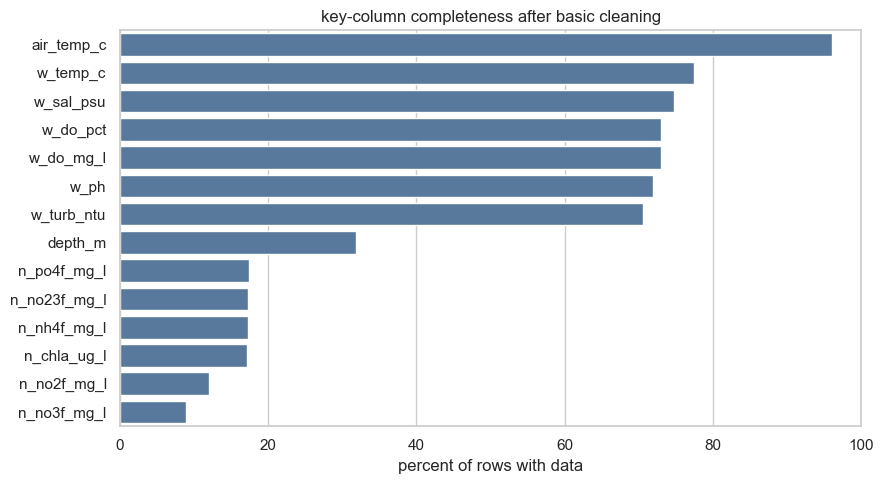


row-level readiness:
temp-link rows: 18,646,664 of 25,277,923 (73.77%)
core-water rows: 6,400,761 of 25,277,923 (25.32%)


In [13]:
# focus on the columns we are most likely to use next
key_cols = [ 
    'w_temp_c',
    'air_temp_c',
    'w_ph',
    'w_sal_psu',
    'w_do_mg_l',
    'w_do_pct',
    'depth_m',
    'w_turb_ntu',
    'n_nh4f_mg_l',
    'n_no2f_mg_l',
    'n_no3f_mg_l',
    'n_po4f_mg_l',
    'n_no23f_mg_l',
    'n_chla_ug_l',
]

key_cols = [ col for col in key_cols if col in data.columns ]

# measure how complete each important column is
completeness_rows = [ ]

for col in key_cols:
    non_null = int( data[ col ].notna( ).sum( ) )
    completeness_rows.append( { 
        'column': col,
        'non_null_rows': non_null,
        'missing_rows': int( len( data ) - non_null ),
        'pct_non_null': round( 100 * non_null / len( data ), 2 ),
    } )

completeness = pd.DataFrame( completeness_rows ).sort_values( 'pct_non_null', ascending = False )
print( completeness )

# show the completeness picture in one quick chart
plt.figure( figsize = ( 9, 5 ) )
sns.barplot( data = completeness, x = 'pct_non_null', y = 'column', color = '#4c78a8' )
plt.title( 'key-column completeness after basic cleaning' )
plt.xlabel( 'percent of rows with data' )
plt.ylabel( '' )
plt.xlim( 0, 100 )
plt.tight_layout( )
plt.show( )

# also measure a few row-level analysis sets
temp_ready_cols = [ col for col in [ 'meta_station_code', 'meta_datetime_stamp', 'w_temp_c', 'air_temp_c' ] if col in data.columns ]
core_water_cols = [ col for col in [ 'w_temp_c', 'w_ph', 'w_sal_psu', 'w_do_mg_l', 'depth_m' ] if col in data.columns ]

temp_ready_rows = int( data[ temp_ready_cols ].notna( ).all( axis = 1 ).sum( ) ) if temp_ready_cols else 0
core_water_rows = int( data[ core_water_cols ].notna( ).all( axis = 1 ).sum( ) ) if core_water_cols else 0

print( )
print( 'row-level readiness:' )
print( f'temp-link rows: {temp_ready_rows:,} of {len( data ):,} ({100 * temp_ready_rows / len( data ):0.2f}%)' )
print( f'core-water rows: {core_water_rows:,} of {len( data ):,} ({100 * core_water_rows / len( data ):0.2f}%)' )

# keep numeric columns focused on measured values for later plots
num_cols = [ col for col in data.select_dtypes( include = np.number ).columns.tolist( ) if not col.endswith( '_flag' ) ]


## 7) simple visualizations


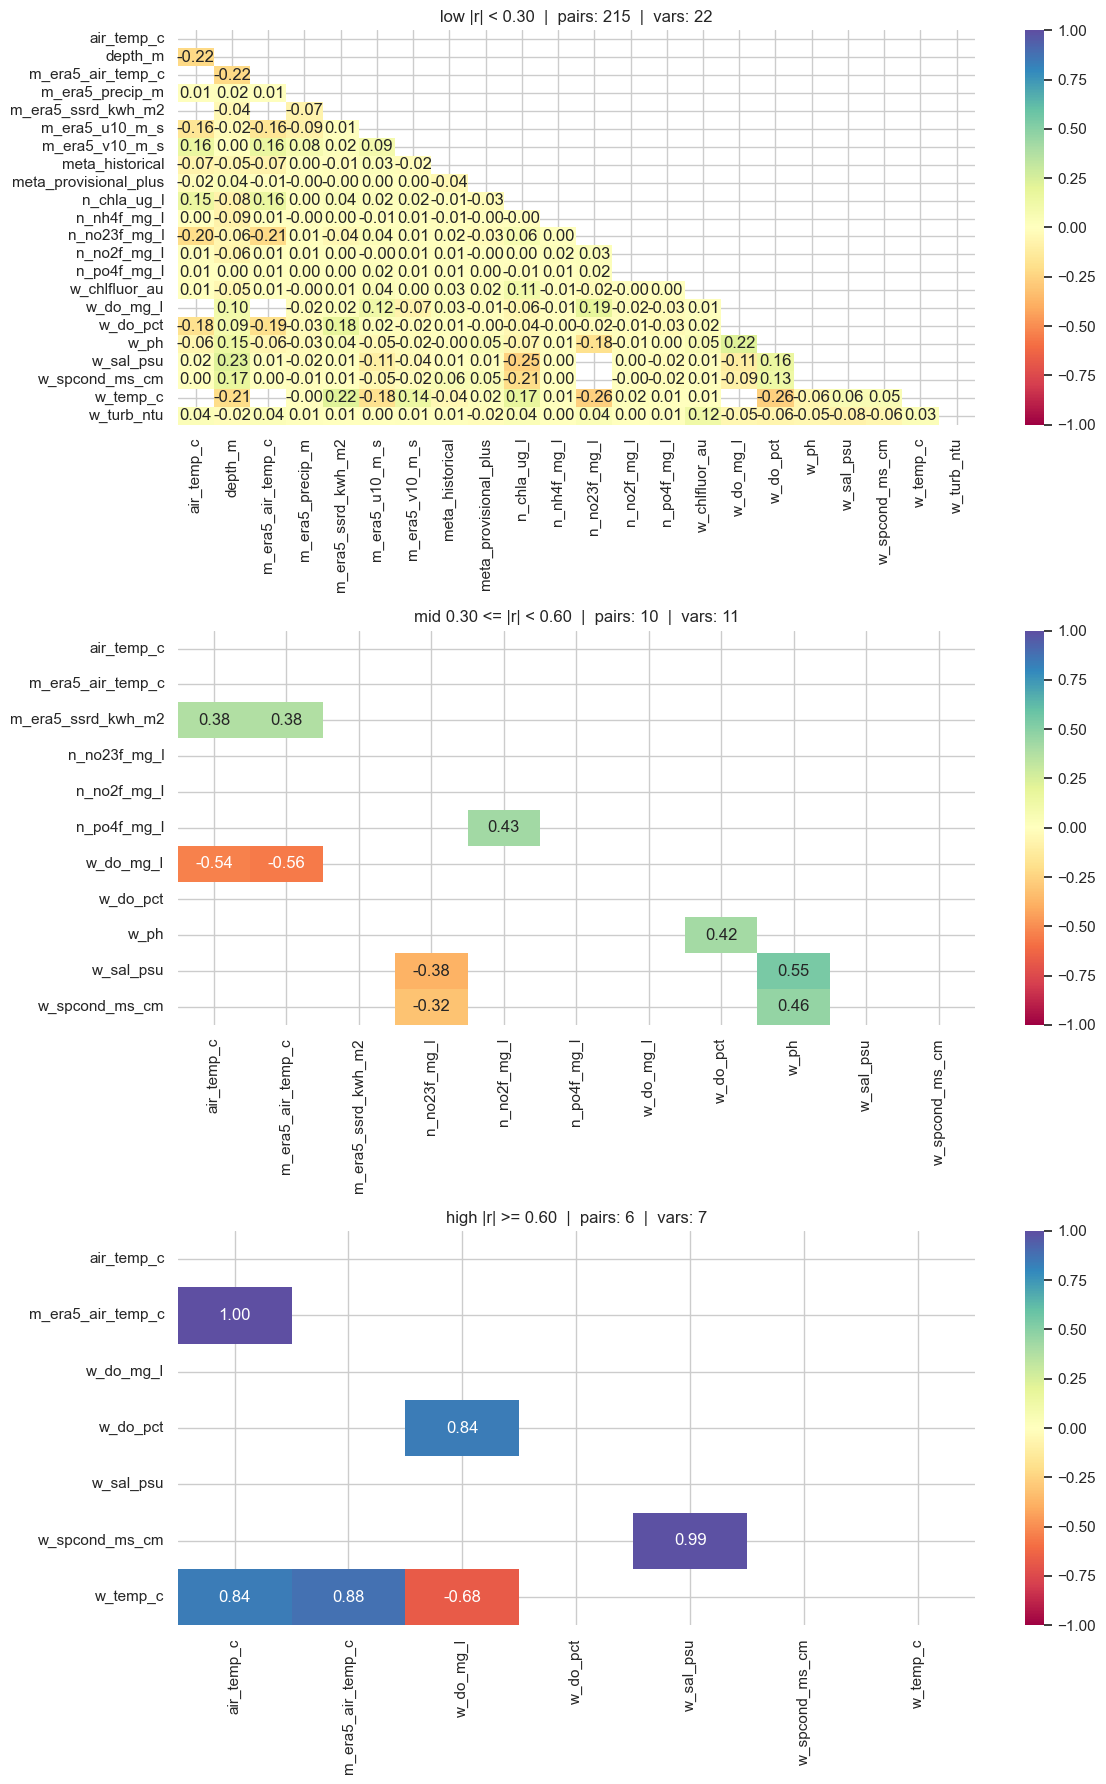


top absolute correlations:
                  var_1               var_2      corr  abs_corr
416   m_era5_air_temp_c          air_temp_c  1.000000  1.000000
185      w_spcond_ms_cm           w_sal_psu  0.988479  0.988479
172            w_temp_c   m_era5_air_temp_c  0.881298  0.881298
174            w_temp_c          air_temp_c  0.842565  0.842565
231            w_do_pct           w_do_mg_l  0.838391  0.838391
165            w_temp_c           w_do_mg_l -0.677397  0.677397
260           w_do_mg_l   m_era5_air_temp_c -0.560146  0.560146
210           w_sal_psu                w_ph  0.545379  0.545379
262           w_do_mg_l          air_temp_c -0.537074  0.537074
188      w_spcond_ms_cm                w_ph  0.464413  0.464413
48          n_po4f_mg_l         n_no2f_mg_l  0.426056  0.426056
232            w_do_pct                w_ph  0.420949  0.420949
438  m_era5_ssrd_kwh_m2          air_temp_c  0.381732  0.381732
415   m_era5_air_temp_c  m_era5_ssrd_kwh_m2  0.381732  0.381732
119        n

In [14]:
# split the correlation view into low, mid, and high absolute-correlation bands
# this is easier to read than one giant annotated matrix
corr_cols = [ col for col in num_cols if data[ col ].notna( ).mean( ) >= 0.10 ]

if len( corr_cols ) < 2:
    print( 'not enough numeric columns for correlation' )

else:
    # build one correlation matrix from columns with at least a little usable data
    corr = data[ corr_cols ].corr( numeric_only = True )

    # keep only one copy of each pair so the band tables stay simple
    corr_pairs = corr.where( np.triu( np.ones_like( corr, dtype = bool ), k = 1 ) )
    corr_pairs = corr_pairs.stack( ).reset_index( )
    corr_pairs.columns = [ 'var_1', 'var_2', 'corr' ]
    corr_pairs[ 'abs_corr' ] = corr_pairs[ 'corr' ].abs( )

    # adjust these cutoffs any time you want tighter or looser groups
    corr_bands = [ 
        ( 'low |r| < 0.30', 0.00, 0.30 ),
        ( 'mid 0.30 <= |r| < 0.60', 0.30, 0.60 ),
        ( 'high |r| >= 0.60', 0.60, 1.01 ),
    ]

    # collect the pairs and variables that belong to each band
    band_results = [ ]

    for label, low_abs, high_abs in corr_bands:
        band_pairs = corr_pairs[ ( corr_pairs[ 'abs_corr' ] >= low_abs ) & ( corr_pairs[ 'abs_corr' ] < high_abs ) ].copy( )
        band_vars = sorted( set( band_pairs[ 'var_1' ] ).union( set( band_pairs[ 'var_2' ] ) ) )
        band_results.append( ( label, band_pairs, band_vars ) )

    # stack the three band-specific matrices in one figure
    fig, axes = plt.subplots( nrows = 3, ncols = 1, figsize = ( 12, 18 ) )

    for ax, ( label, band_pairs, band_vars ) in zip( axes, band_results ):
        if len( band_vars ) < 2:
            ax.axis( 'off' )
            ax.text( 0.5, 0.5, f'{label}\nno pairs in this band', ha = 'center', va = 'center' )

        else:
            # start with an empty matrix and fill only the pairs from this band
            band_corr = pd.DataFrame( np.nan, index = band_vars, columns = band_vars )

            for _, row in band_pairs.iterrows( ):
                band_corr.loc[ row[ 'var_1' ], row[ 'var_2' ] ] = row[ 'corr' ]
                band_corr.loc[ row[ 'var_2' ], row[ 'var_1' ] ] = row[ 'corr' ]

            mask = np.triu( np.ones_like( band_corr, dtype = bool ) ) | band_corr.isna( )
            sns.heatmap( 
                band_corr,
                cmap = 'Spectral',
                vmin = -1,
                vmax = 1,
                annot = True,
                fmt = '.2f',
                mask = mask,
                ax = ax,
                cbar = True,
            )
            ax.set_title( f'{label}  |  pairs: {len( band_pairs )}  |  vars: {len( band_vars )}' )

    plt.tight_layout( )
    plt.show( )

    # print the strongest pairs too, so we can scan them without reading the heatmap
    print( )
    print( 'top absolute correlations:' )
    print( corr_pairs.sort_values( 'abs_corr', ascending = False ).head( 20 ) )


## 8) response-time note

pause lag imputation for now

the next pass will work from a reduced column set first, then revisit response-time features if still needed


In [15]:
# keep the notebook simple for now
# do this separately in the next two notebooks for nutrient responses and timeline analysis of water overall

## 9) reduce to the columns we actually need

keep a compact modeling table, then create a strict complete-case table and a broader trend table


In [16]:
# remove lag and gap helpers if they are still present from older notebook runs
old_helper_cols = [ 
    col
    for col in [ 'air_temp_c_lag_best', 'air_water_temp_gap_c', 'estimated_response_hours' ]
    if col in data.columns
]

if old_helper_cols:
    data = data.drop( columns = old_helper_cols )

# start by copying the cleaned table so the next steps are explicit
analysis_data = data.copy( )

# keep region, station, and datetime in a compact form
if 'region_code' in analysis_data.columns:
    analysis_data[ 'region' ] = analysis_data[ 'region_code' ]

if 'meta_station_code' in analysis_data.columns:
    station_letters = analysis_data[ 'meta_station_code' ].astype( str ).str.extract( r'([A-Za-z]{2})$' )[ 0 ]
    analysis_data[ 'station' ] = station_letters.fillna( analysis_data[ 'meta_station_code' ].astype( str ).str[ -2: ] ).str.lower( )

if 'meta_datetime_stamp' in analysis_data.columns:
    analysis_data[ 'datetime' ] = analysis_data[ 'meta_datetime_stamp' ]

# combine ERA5 wind components into one speed metric
if 'm_era5_u10_m_s' in analysis_data.columns and 'm_era5_v10_m_s' in analysis_data.columns:
    u10 = pd.to_numeric( analysis_data[ 'm_era5_u10_m_s' ], errors = 'coerce' )
    v10 = pd.to_numeric( analysis_data[ 'm_era5_v10_m_s' ], errors = 'coerce' )
    analysis_data[ 'm_wind_ms' ] = np.sqrt( ( u10 ** 2 ) + ( v10 ** 2 ) )

# rename or derive the ERA5 meteorology fields we want to keep
if 'm_era5_ssrd_kwh_m2' in analysis_data.columns:
    analysis_data[ 'm_ssrd_kwh_m2' ] = pd.to_numeric( analysis_data[ 'm_era5_ssrd_kwh_m2' ], errors = 'coerce' )

if 'm_era5_precip_m' in analysis_data.columns:
    analysis_data[ 'm_precip_mmh' ] = pd.to_numeric( analysis_data[ 'm_era5_precip_m' ], errors = 'coerce' ) * 1000

if 'air_temp_c' in analysis_data.columns:
    analysis_data[ 'm_temp_c' ] = pd.to_numeric( analysis_data[ 'air_temp_c' ], errors = 'coerce' )

# keep only the columns we need for the two output tables
keep_cols = [ 
    'region',
    'station',
    'datetime',
    'n_po4f_mg_l',
    'n_nh4f_mg_l',
    'n_no2f_mg_l',
    'n_no3f_mg_l',
    'n_no23f_mg_l',
    'n_chla_ug_l',
    'w_temp_c',
    'w_sal_psu',
    'w_do_mg_l',
    'w_do_pct',
    'depth_m',
    'w_ph',
    'm_wind_ms',
    'm_ssrd_kwh_m2',
    'm_precip_mmh',
    'm_temp_c',
]

keep_cols = [ col for col in keep_cols if col in analysis_data.columns ]
analysis_data = analysis_data[ keep_cols ].copy( )

print( 'reduced columns:' )
print( analysis_data.columns.tolist( ) )
print( f'rows in reduced table: {len( analysis_data ):,}' )

# strict complete-case table for nutrient-response work
complete_records = analysis_data.dropna( ).copy( )
print( )
print( f'complete nutrient-response rows: {len( complete_records ):,}' )

# broader trend table: drop nutrient columns before requiring complete rows
nutrient_cols = [ col for col in [ 'n_po4f_mg_l', 'n_nh4f_mg_l', 'n_no2f_mg_l', 'n_no3f_mg_l', 'n_no23f_mg_l', 'n_chla_ug_l' ] if col in analysis_data.columns ]
trend_source = analysis_data.drop( columns = nutrient_cols )
trend_records = trend_source.dropna( ).copy( ) # complete records may undermine our effort for trends
print( f'complete trend rows: {len( trend_source ):,}' )


reduced columns:
['region', 'station', 'datetime', 'n_po4f_mg_l', 'n_nh4f_mg_l', 'n_no2f_mg_l', 'n_no3f_mg_l', 'n_no23f_mg_l', 'n_chla_ug_l', 'w_temp_c', 'w_sal_psu', 'w_do_mg_l', 'w_do_pct', 'depth_m', 'w_ph', 'm_wind_ms', 'm_ssrd_kwh_m2', 'm_precip_mmh', 'm_temp_c']
rows in reduced table: 25,277,923

complete nutrient-response rows: 590,186
complete trend rows: 25,277,923


## 10) save reduced analysis tables

write out both the strict complete-case table and the broader trend table


In [17]:
# save the reduced tables next to the source file
complete_output_path = data_path.with_name( data_path.stem + '_complete_records.csv' )
trend_output_path = data_path.with_name( data_path.stem + '_trend_records.csv' )

out_nutrients = data_dir / f't4d.{resolution}hr.nutrients.csv'
out_history = data_dir / f't4d.{resolution}hr.water.history.csv'
complete_records.to_csv( out_nutrients, index = False )
trend_source.to_csv( out_history, index = False )

print( f'saved complete records: {out_nutrients}' )
print( f'saved trend records: {out_history}' )

saved complete records: ../data/1hr/t4d.1hr.nutrients.csv
saved trend records: ../data/1hr/t4d.1hr.water.history.csv
